In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("WARNING: XGBoost is not installed.")
    print("Install it using: pip install xgboost")


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset: Breast Cancer Wisconsin Dataset")
print("Source: scikit-learn (Wisconsin Diagnostic Breast Cancer dataset)")
print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget classes:")
print(data.target_names)

print("\nClass distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])



scaler = StandardScaler()


scaler_temp = StandardScaler()

X_train_scaled = scaler_temp.fit_transform(X_train)

pca_temp = PCA()
pca_temp.fit(X_train_scaled)

cumulative_variance = np.cumsum(
    pca_temp.explained_variance_ratio_
)

n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("\n" + "=" * 70)
print("PCA INFORMATION")
print("=" * 70)

print("Original number of features:", X.shape[1])
print("Components selected for 95% variance:", n_components)
print(
    "Explained variance:",
    cumulative_variance[n_components - 1] * 100,
    "%"
)


DATASET INFORMATION
Dataset: Breast Cancer Wisconsin Dataset
Source: scikit-learn (Wisconsin Diagnostic Breast Cancer dataset)
Number of samples : 569
Number of features: 30

Target classes:
['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values:
0

Training samples: 455
Testing samples : 114

PCA INFORMATION
Original number of features: 30
Components selected for 95% variance: 10
Explained variance: 95.26768937417546 %


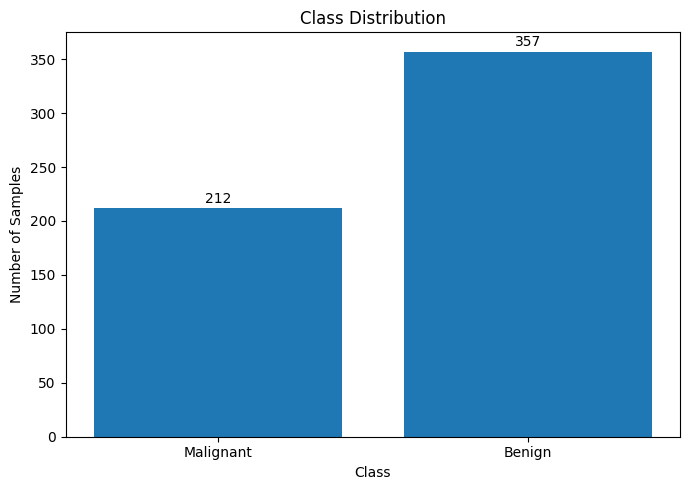

In [10]:
class_counts = y.value_counts()
plt.figure(figsize=(7, 5))

plt.bar(
    ["Malignant", "Benign"],
    [class_counts[0], class_counts[1]]
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
for i, value in enumerate([class_counts[0], class_counts[1]]):
    plt.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

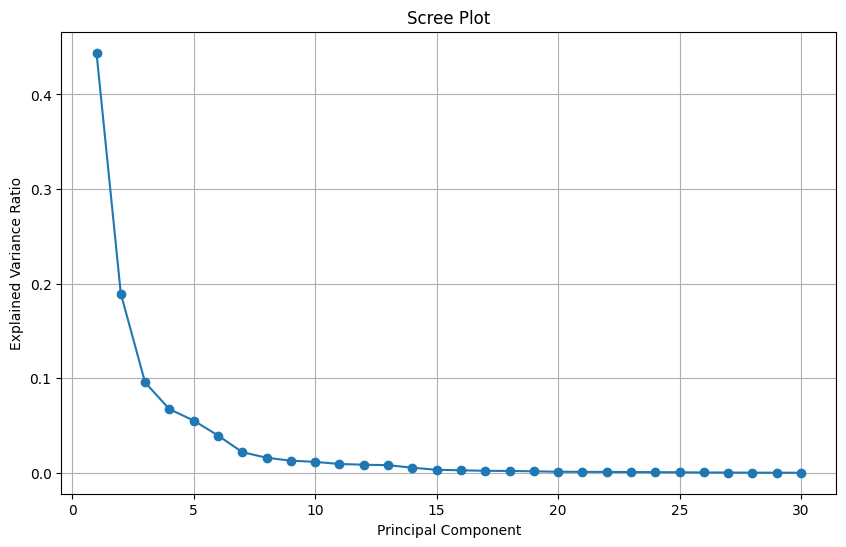

In [2]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(pca_temp.explained_variance_ratio_) + 1),
    pca_temp.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)
plt.show()


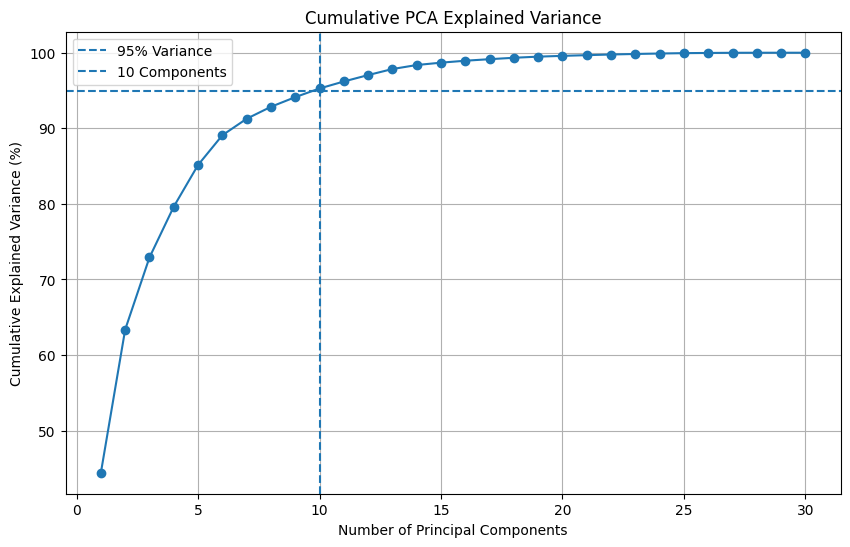

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=n_components,
    linestyle="--",
    label=f"{n_components} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative PCA Explained Variance")

plt.legend()
plt.grid(True)
plt.show()


In [4]:
models = {

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

param_grids = {

    "SVM": {
        "classifier__kernel": ["linear", "rbf"],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "classifier__var_smoothing": [
            1e-9,
            1e-8,
            1e-7
        ]
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["liblinear"]
    },

    "Decision Tree": {
        "classifier__max_depth": [None, 3, 5, 10],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5]
    },

    "AdaBoost": {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__learning_rate": [0.01, 0.1, 1]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [2, 3]
    }
}



In [5]:

if XGBOOST_AVAILABLE:

    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    param_grids["XGBoost"] = {
        "classifier__n_estimators": [50, 100],
        "classifier__max_depth": [3, 5],
        "classifier__learning_rate": [0.05, 0.1]
    }

stack_estimators = [

    (
        "lr",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    ),

    (
        "svm",
        SVC(
            probability=True,
            random_state=42
        )
    ),

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
]

stacking_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(
        max_iter=5000
    )
)

models["Stacking"] = stacking_model

param_grids["Stacking"] = {
    "classifier__final_estimator__C": [0.1, 1, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [6]:

def train_model(
    model_name,
    model,
    param_grid,
    use_pca=False
):

    print("\n" + "=" * 70)

    if use_pca:
        print(f"{model_name} - WITH PCA")
    else:
        print(f"{model_name} - WITHOUT PCA")

    print("=" * 70)

    steps = [
        ("scaler", StandardScaler())
    ]

    if use_pca:
        steps.append(
            (
                "pca",
                PCA(
                    n_components=n_components
                )
            )
        )

    steps.append(
        ("classifier", model)
    )

    pipeline = Pipeline(steps)

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(
        X_train,
        y_train
    )

    print("Best Parameters:")
    print(grid_search.best_params_)

    print(
        "Best CV Accuracy:",
        round(grid_search.best_score_, 4)
    )


    best_model = grid_search.best_estimator_

    cv_results = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "f1"
        ],
        return_train_score=False,
        n_jobs=-1
    )

    fold_accuracy = cv_results["test_accuracy"]

    fold_f1 = cv_results["test_f1"]

    print("\nFold-wise Accuracy:")

    for i, score in enumerate(
        fold_accuracy,
        start=1
    ):
        print(
            f"Fold {i}: {score:.4f}"
        )

    print(
        "Average Accuracy:",
        round(fold_accuracy.mean(), 4)
    )

    print(
        "Average F1:",
        round(fold_f1.mean(), 4)
    )

    best_model.fit(
        X_train,
        y_train
    )


    y_pred = best_model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    print("\nTest Accuracy:", round(accuracy, 4))
    print("Test F1 Score :", round(f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=data.target_names
        )
    )


    return {
        "model": best_model,
        "best_params": grid_search.best_params_,
        "fold_scores": fold_accuracy,
        "fold_f1": fold_f1,
        "cv_accuracy": fold_accuracy.mean(),
        "cv_f1": fold_f1.mean(),
        "test_accuracy": accuracy,
        "test_f1": f1
    }


In [7]:


results_no_pca = {}

for name, model in models.items():

    results_no_pca[name] = train_model(
        name,
        model,
        param_grids[name],
        use_pca=False
    )

results_pca = {}

for name, model in models.items():

    results_pca[name] = train_model(
        name,
        model,
        param_grids[name],
        use_pca=True
    )

rows = []

for name in models.keys():

    no_pca = results_no_pca[name]
    pca = results_pca[name]

    rows.append({

        "Model": name,

        "No-PCA Fold 1":
            no_pca["fold_scores"][0],

        "No-PCA Fold 2":
            no_pca["fold_scores"][1],

        "No-PCA Fold 3":
            no_pca["fold_scores"][2],

        "No-PCA Fold 4":
            no_pca["fold_scores"][3],

        "No-PCA Fold 5":
            no_pca["fold_scores"][4],

        "No-PCA Avg Accuracy":
            no_pca["cv_accuracy"],

        "With-PCA Fold 1":
            pca["fold_scores"][0],

        "With-PCA Fold 2":
            pca["fold_scores"][1],

        "With-PCA Fold 3":
            pca["fold_scores"][2],

        "With-PCA Fold 4":
            pca["fold_scores"][3],

        "With-PCA Fold 5":
            pca["fold_scores"][4],

        "With-PCA Avg Accuracy":
            pca["cv_accuracy"],

        "No-PCA Test Accuracy":
            no_pca["test_accuracy"],

        "With-PCA Test Accuracy":
            pca["test_accuracy"],

        "No-PCA F1":
            no_pca["test_f1"],

        "With-PCA F1":
            pca["test_f1"]
    })


results_df = pd.DataFrame(rows)


SVM - WITHOUT PCA
Best Parameters:
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV Accuracy: 0.9758

Fold-wise Accuracy:
Fold 1: 0.9560
Fold 2: 0.9780
Fold 3: 0.9780
Fold 4: 0.9780
Fold 5: 0.9890
Average Accuracy: 0.9758
Average F1: 0.981

Test Accuracy: 0.9825
Test F1 Score : 0.9861

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Naive Bayes - WITHOUT PCA
Best Parameters:
{'classifier__var_smoothing': 1e-09}
Best CV Accuracy: 0.9341

Fold-wise Accuracy:
Fold 1: 0.9121
Fold 2: 0.9670
Fold 3: 0.8901
Fold 4: 0.9560
Fold 5: 0.9451
Average Accuracy: 0.9341
Average F1: 0.9478

Test Accuracy: 0.9298
Test F1 Score : 0.9444

Classification Report:
  




FINAL COMPARISON: NO PCA vs WITH PCA
              Model  No-PCA Avg Accuracy  With-PCA Avg Accuracy  No-PCA Test Accuracy  With-PCA Test Accuracy  No-PCA F1  With-PCA F1
                SVM               0.9758                 0.9802                0.9825                  0.9649     0.9861       0.9718
        Naive Bayes               0.9341                 0.9275                0.9298                  0.9211     0.9444       0.9379
                KNN               0.9714                 0.9670                0.9649                  0.9561     0.9726       0.9655
Logistic Regression               0.9824                 0.9802                0.9825                  0.9649     0.9861       0.9718
      Decision Tree               0.9319                 0.9363                0.9474                  0.9298     0.9589       0.9444
      Random Forest               0.9626                 0.9604                0.9561                  0.9298     0.9655       0.9444
           AdaBoost   

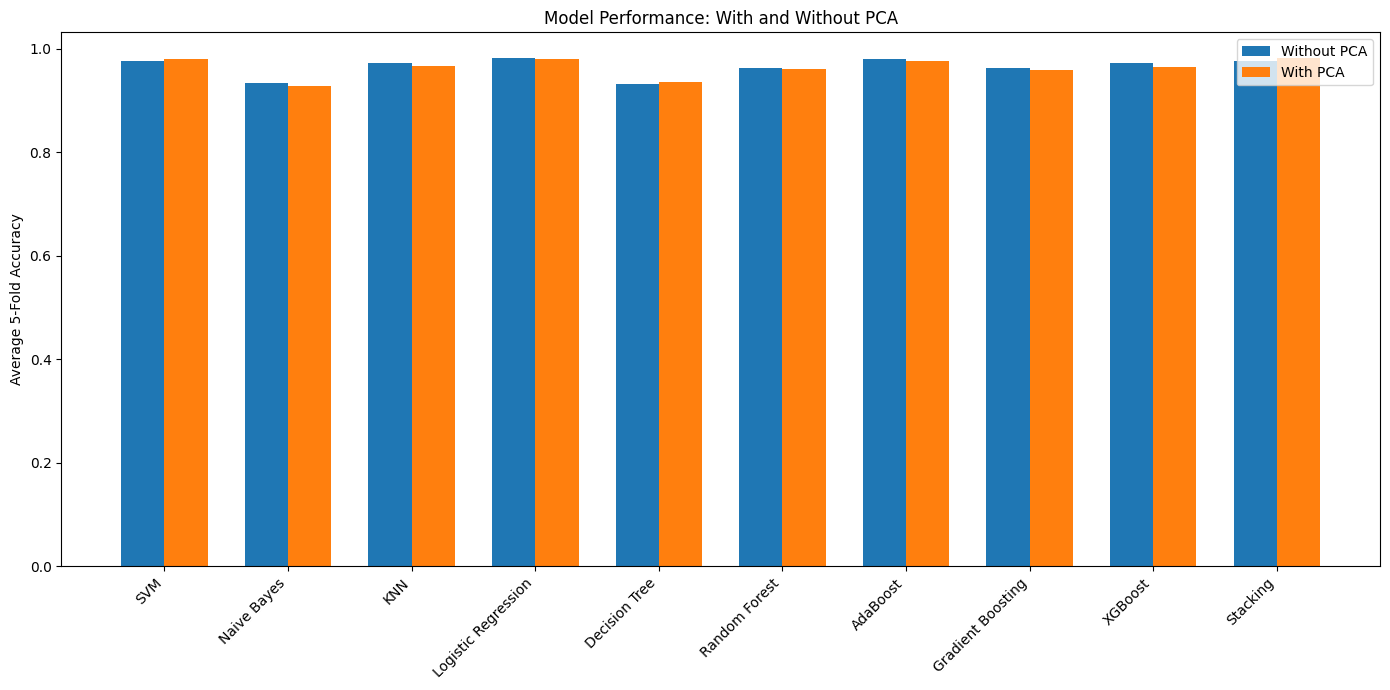


BEST MODELS
Best model WITHOUT PCA: Logistic Regression
Accuracy: 0.9824

Best model WITH PCA: Stacking
Accuracy: 0.9824


<Figure size 600x500 with 0 Axes>

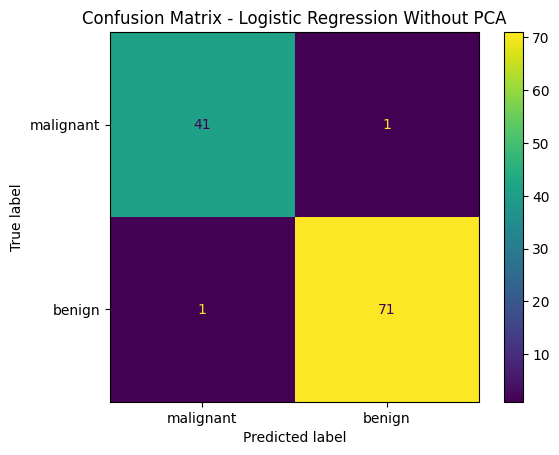

<Figure size 600x500 with 0 Axes>

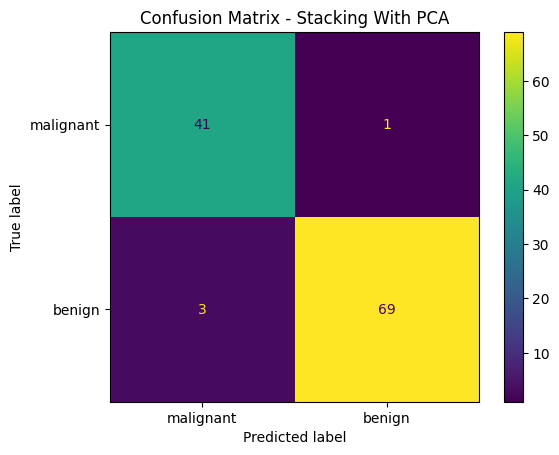

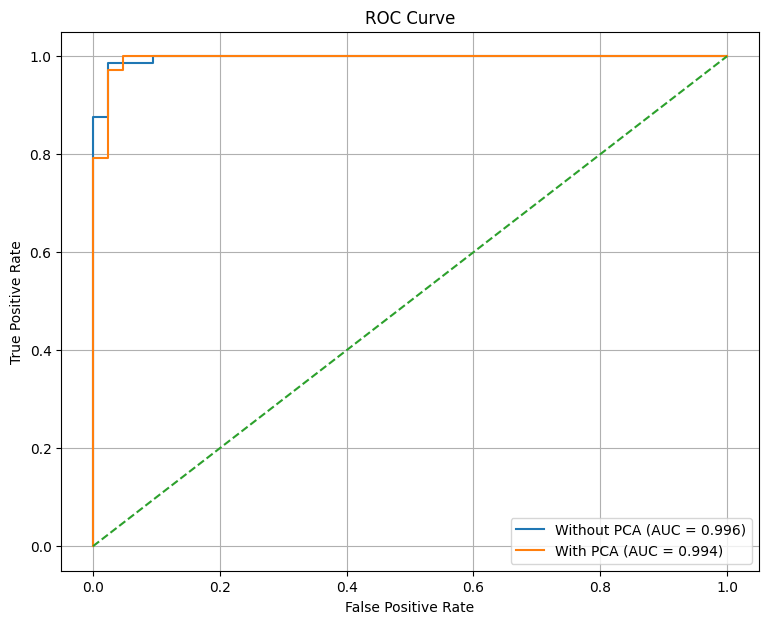

In [8]:

print("\n\n")
print("=" * 100)
print("FINAL COMPARISON: NO PCA vs WITH PCA")
print("=" * 100)

print(
    results_df[
        [
            "Model",
            "No-PCA Avg Accuracy",
            "With-PCA Avg Accuracy",
            "No-PCA Test Accuracy",
            "With-PCA Test Accuracy",
            "No-PCA F1",
            "With-PCA F1"
        ]
    ].round(4).to_string(index=False)
)

results_df["Accuracy Improvement"] = (
    results_df["With-PCA Avg Accuracy"]
    -
    results_df["No-PCA Avg Accuracy"]
)

print("\n" + "=" * 70)
print("PCA IMPROVEMENT")
print("=" * 70)

print(
    results_df[
        [
            "Model",
            "No-PCA Avg Accuracy",
            "With-PCA Avg Accuracy",
            "Accuracy Improvement"
        ]
    ].round(4).to_string(index=False)
)

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    results_df["No-PCA Avg Accuracy"],
    width,
    label="Without PCA"
)

plt.bar(
    x + width / 2,
    results_df["With-PCA Avg Accuracy"],
    width,
    label="With PCA"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Average 5-Fold Accuracy")
plt.title("Model Performance: With and Without PCA")

plt.legend()
plt.tight_layout()
plt.show()

best_no_pca = results_df.loc[
    results_df["No-PCA Avg Accuracy"].idxmax()
]

best_pca = results_df.loc[
    results_df["With-PCA Avg Accuracy"].idxmax()
]

print("\n" + "=" * 70)
print("BEST MODELS")
print("=" * 70)

print(
    "Best model WITHOUT PCA:",
    best_no_pca["Model"]
)

print(
    "Accuracy:",
    round(
        best_no_pca["No-PCA Avg Accuracy"],
        4
    )
)

print(
    "\nBest model WITH PCA:",
    best_pca["Model"]
)

print(
    "Accuracy:",
    round(
        best_pca["With-PCA Avg Accuracy"],
        4
    )
)

best_no_pca_name = best_no_pca["Model"]
best_pca_name = best_pca["Model"]

best_no_pca_model = (
    results_no_pca[
        best_no_pca_name
    ]["model"]
)

best_pca_model = (
    results_pca[
        best_pca_name
    ]["model"]
)

y_pred_no_pca = best_no_pca_model.predict(
    X_test
)

y_pred_pca = best_pca_model.predict(
    X_test
)

plt.figure(figsize=(6, 5))

cm = confusion_matrix(
    y_test,
    y_pred_no_pca
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title(
    f"Confusion Matrix - {best_no_pca_name} Without PCA"
)

plt.show()

plt.figure(figsize=(6, 5))

cm = confusion_matrix(
    y_test,
    y_pred_pca
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title(
    f"Confusion Matrix - {best_pca_name} With PCA"
)

plt.show()

plt.figure(figsize=(9, 7))

if hasattr(
    best_no_pca_model,
    "predict_proba"
):

    y_prob_no_pca = (
        best_no_pca_model
        .predict_proba(X_test)[:, 1]
    )

else:

    y_prob_no_pca = (
        best_no_pca_model
        .decision_function(X_test)
    )


fpr_no_pca, tpr_no_pca, _ = roc_curve(
    y_test,
    y_prob_no_pca
)

auc_no_pca = auc(
    fpr_no_pca,
    tpr_no_pca
)


if hasattr(
    best_pca_model,
    "predict_proba"
):

    y_prob_pca = (
        best_pca_model
        .predict_proba(X_test)[:, 1]
    )

else:

    y_prob_pca = (
        best_pca_model
        .decision_function(X_test)
    )


fpr_pca, tpr_pca, _ = roc_curve(
    y_test,
    y_prob_pca
)

auc_pca = auc(
    fpr_pca,
    tpr_pca
)


plt.plot(
    fpr_no_pca,
    tpr_no_pca,
    label=f"Without PCA (AUC = {auc_no_pca:.3f})"
)

plt.plot(
    fpr_pca,
    tpr_pca,
    label=f"With PCA (AUC = {auc_pca:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid(True)
plt.show()

In [9]:
results_df.to_csv(
    "PCA_Model_Comparison.csv",
    index=False
)

print("\nResults saved to:")
print("PCA_Model_Comparison.csv")


print("\n" + "=" * 70)
print("FINAL OBSERVATION")
print("=" * 70)

for _, row in results_df.iterrows():

    improvement = row["Accuracy Improvement"]

    if improvement > 0:
        status = "PCA IMPROVED performance"

    elif improvement < 0:
        status = "PCA REDUCED performance"

    else:
        status = "PCA had NO significant change"

    print(
        f"{row['Model']}: "
        f"{status} "
        f"({improvement:+.4f})"
    )

print("\nExperiment completed successfully.")


Results saved to:
PCA_Model_Comparison.csv

FINAL OBSERVATION
SVM: PCA IMPROVED performance (+0.0044)
Naive Bayes: PCA REDUCED performance (-0.0066)
KNN: PCA REDUCED performance (-0.0044)
Logistic Regression: PCA REDUCED performance (-0.0022)
Decision Tree: PCA IMPROVED performance (+0.0044)
Random Forest: PCA REDUCED performance (-0.0022)
AdaBoost: PCA REDUCED performance (-0.0044)
Gradient Boosting: PCA REDUCED performance (-0.0044)
XGBoost: PCA REDUCED performance (-0.0066)
Stacking: PCA IMPROVED performance (+0.0066)

Experiment completed successfully.
